In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [33]:
df = sns.load_dataset('titanic')

In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [35]:
print(df.shape)
print(df.info())

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [36]:

print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


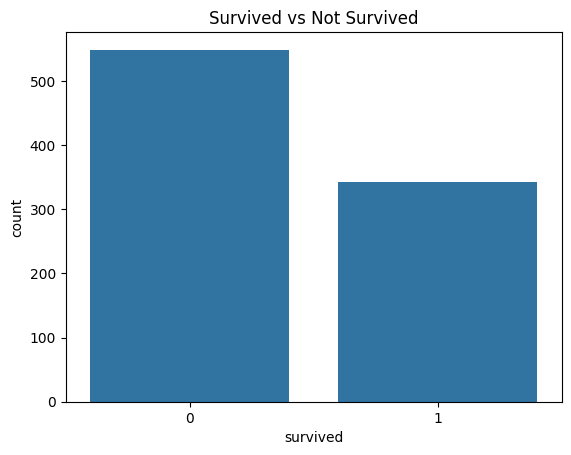

In [37]:
sns.countplot(x='survived', data=df)
plt.title('Survived vs Not Survived')
plt.show()

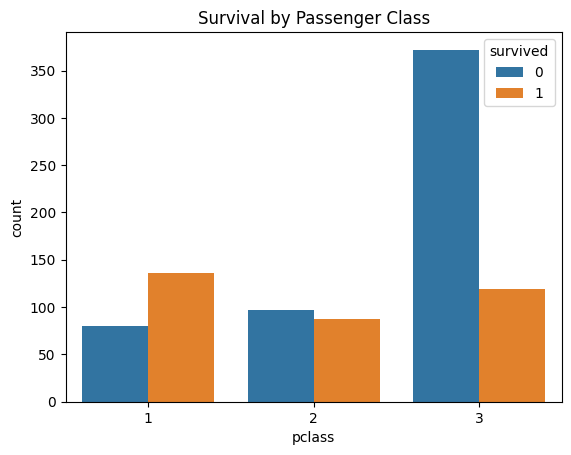

In [38]:
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

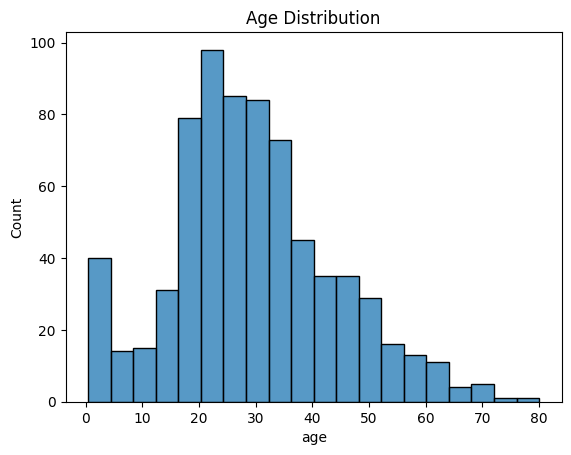

In [39]:
sns.histplot(df['age'], bins=20)
plt.title('Age Distribution')
plt.show()

In [40]:
df['age'] = df['age'].fillna(df['age'].median())

In [41]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [42]:
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

In [43]:
df.drop('deck', axis=1, inplace=True)

In [44]:
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [45]:
df = df[['pclass', 'sex', 'age', 'fare', 'survived']]

In [46]:
y = df['survived']

In [47]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['sex'] = encoder.fit_transform(df['sex'])

In [48]:
X = df.drop('survived', axis=1)
y = df['survived']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
from sklearn.neighbors import KNeighborsClassifier

In [52]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [53]:
y_pred = knn.predict(X_test)

In [54]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8212290502793296


In [55]:
print(confusion_matrix(y_test, y_pred))

[[93 12]
 [20 54]]


In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [57]:
scores = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    scores.append(accuracy_score(y_test, pred))

print(scores)

[0.776536312849162, 0.7877094972067039, 0.7653631284916201, 0.7932960893854749, 0.8212290502793296, 0.7988826815642458, 0.8156424581005587, 0.8100558659217877, 0.8212290502793296, 0.7932960893854749, 0.7988826815642458, 0.7988826815642458, 0.7988826815642458, 0.8044692737430168, 0.7988826815642458, 0.7653631284916201, 0.7597765363128491, 0.7597765363128491, 0.7597765363128491, 0.7597765363128491]


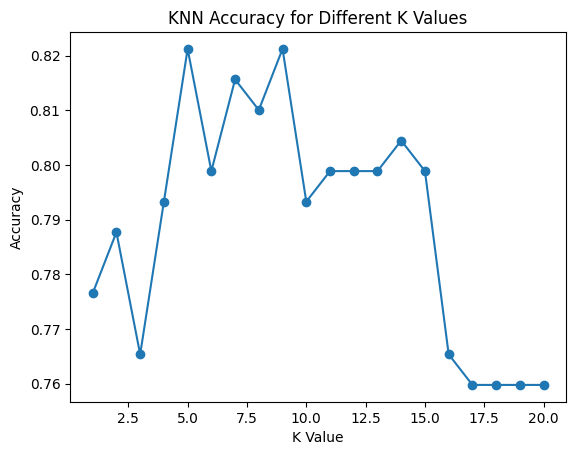

In [58]:
import matplotlib.pyplot as plt

plt.plot(range(1, 21), scores, marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different K Values')
plt.show()